# Aprendizaje online y gradiente descendente estocástico
## Definición del problema de estimación de parámetros

Se desean encontra los parámetros w_0 y w_1 del siguiente modelo de regresión entre las variables x y y:

$$y_i = w_1 x_i + w_0 + e_i$$

a partir de un conjunto de observaciones $\{d_i, x_i\}$, donde d_i es el valor real (observado), y_i es su aproximación usando el modelo de regresión descrito, y e_i es el error.

ya sabemos que 

La sumatoria de errores al cuadrado es definido como:

$$\text{SSE}(w_0, w_1) = \sum_i (d_i - y_i)^2$$

Si se tiene en cuenta que el error instantáneo se define como:

$$e_i = d_i - y_i$$

la ecuación anterior se puede reescribir como:

\begin{split} \text{SSE}(w_0, w_1) & = \sum_i (d_i - y_i)^2 \\ & = \sum_i e_i^2 \end{split}

## Con el aprendizaje batch (cálculo por medio del método del gradiente descendente)

\begin{split} \mathbf{w}_k & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1}) \\ & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \left( \sum_i e_i^2 \right) \end{split}

donde $\mathbf{w} = [w_0, w_1]$.

La ecuación anterior se puede reescribir como:

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \sum_i \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

que es calculando la derivada en cada punto específico de error. 

## Aprendizaje online
El aprendizaje online se obteiene al hacer una corrección de los parámetros de forma secuencial para cada punto $i$. El nombre se deriva del hecho de que los puntos

$$(x_i,y_i)$$

pueden presentarse al algoritmo como un stream de datos.

Es decir, la ecuación de corrección cambia a:

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

#l proceso es el siguiente:

* Se computa el gradiente instantáneo para el punto i. (calcular derivada)

* Se realiza la corrección del vector de parámetros $\mathbf{w}$_k con el gradiente para el punto i.

* Se pasa al siguiente punto (i = i + 1) y se rotorna al primer paso.

en este caso se necesitan las derivadas instantáneas las cuales son: 

\begin{split} \frac{\partial}{\partial w_0} e^2_i & = -2 e_i \\ \end{split}

\begin{split} \frac{\partial}{\partial w_1} e^2_i & = -2 e_i x_i \\ \end{split}





In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [2]:
#
# Datos del problema
#
x_sample = [
    0.6231,
    0.7460,
    0.1087,
    0.3654,
    0.3065,
    0.6886,
    0.4966,
    0.2618,
    0.7607,
    0.4424,
    0.7731,
]

y_sample = [
    1.6266,
    1.8508,
    0.9519,
    1.2828,
    1.2283,
    1.8722,
    1.4657,
    1.1097,
    1.7826,
    1.4267,
    1.8248,
]

In [3]:
#
# Sumatoria del error cuadrático o pérdida cuadrática
#
def sse(w0, w1):
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]
    squared_errors = [error ** 2 for error in errors]
    return sum(squared_errors)

In [4]:
def plot_contour():

    W0 = np.linspace(0.0, 0.8, 50)
    W1 = np.linspace(2.4, 3.2, 50)
    W0, W1 = np.meshgrid(W0, W1)
    F = sse(W0, W1)

    levels = [0, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10, 20, 40, 60]

    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    ax.set_aspect("equal", "box")
    ax.contourf(W0, W1, F, cmap=cm.Greys, levels=levels, alpha=0.8)
    ax.contour(W0, W1, F, colors="gray", levels=levels)
    ax.grid()
    ax.set_xlabel("w0")
    ax.set_ylabel("w1")

In [ ]:
def gradient(w0, w1, x_value, y_value):

    error = y_value - w0 - w1 * x_value
    #notese que las formulas salen explíticasa
    #como dervicadas analíticas.
    gradient_w0 = -2 * error
    gradient_w1 = -2 * error * x_value

    return gradient_w0, gradient_w1

Ecuación de mejora
$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

In [7]:
def improve(w0, w1, mu, x_value, y_value):

    gradient_w0, gradient_w1 = gradient(w0, w1, x_value, y_value)
    w0 = w0 - mu * gradient_w0
    w1 = w1 - mu * gradient_w1

    return w0, w1

 w0 = 0.2106
 w1 = 2.4542
SSE = 0.6276



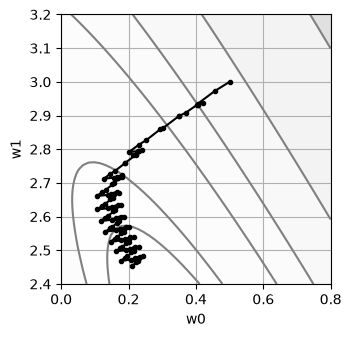

In [8]:
# proceso iterativo del aprendizaje online
#
# Punto de inicio
#
w0 = 0.5
w1 = 3.0

history = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

mu = 0.03

for epoch in range(10):

    for x_value, y_value in zip(x_sample, y_sample):

        w0, w1 = improve(w0, w1, mu, x_value, y_value)

        history["w0"].append(w0)
        history["w1"].append(w1)
        history["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}\n".format(w0, w1, sse(w0, w1)))

plot_contour()
plt.plot(history["w0"], history["w1"], marker=".", color="black")
plt.show()

In [ ]:
# reduccción de la suma del cuadrado de los residuos al incrementar 
#las iteraciones
plt.figure(figsize=(10, 3.5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

El descenso por gradiente online se diferencia del descednso por gradiente tradicional en la cantidad de datos que procesa para realizar una sola actualización de los parámetros. 

Batch Gradient Descent (Tradicional): Espera a procesar TODO el conjunto de datos de entrenamiento para calcular el gradiente global y hacer una sola actualización de los pesos. Por eso es es que el cálculo del vector gradiente se hace sobre la suma del cuadrado de los residuos

\begin{split} \mathbf{w}_k & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1}) \\ & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \left( \sum_i e_i^2 \right) \end{split}

En su lugar, Online Gradient Descent: Procesa UN SOLO dato a la vez. Inmediatamente calcula la pérdida, actualiza los pesos y descarta (o pasa al siguiente) ese dato. Como es de a un solo dato por ello es que pueden llegar los demás de a uno. Como online

